In [1]:
import os
import torch
from PIL import Image
from tqdm.auto import tqdm
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from diffusers import StableDiffusionPipeline

In [2]:
%cd /scratch/RDS_RS02810_AML/

/scratch/RDS_RS02810_AML


In [3]:
MODEL_PATH = "/scratch/RDS_RS02810_AML/final_sd14_model"

IDENTITY = "5247"

INSTANCE_DIR = f"/scratch/RDS_RS02810_AML/celebahq_by_identity/{IDENTITY}"

CLASS_DIR = "/scratch/RDS_RS02810_AML/class_images_person"

OUTPUT_DIR = f"/scratch/RDS_RS02810_AML/dreambooth_{IDENTITY}"

DEVICE = "cuda"

NUM_CLASS_IMAGES = 300

INSTANCE_PROMPT = "photo of sks_person"

CLASS_PROMPT = "photo of a person"


In [4]:
os.makedirs(CLASS_DIR, exist_ok=True)

existing_images = len(os.listdir(CLASS_DIR))

if existing_images < NUM_CLASS_IMAGES:

    pipe = StableDiffusionPipeline.from_pretrained(
        MODEL_PATH,
        torch_dtype=torch.float16
    ).to(DEVICE)

    # DISABLE INTERNAL DIFFUSERS BARS
    pipe.set_progress_bar_config(disable=True)

    print(f"Generating {NUM_CLASS_IMAGES-existing_images} class images...")

    progress = tqdm(
        total=NUM_CLASS_IMAGES-existing_images,
        desc="Class Images"
    )

    for i in range(existing_images, NUM_CLASS_IMAGES):

        image = pipe(
            CLASS_PROMPT,
            num_inference_steps=30,
            guidance_scale=7.5
        ).images[0]

        image.save(os.path.join(CLASS_DIR, f"class_{i}.png"))

        progress.update(1)

    progress.close()

    del pipe
    torch.cuda.empty_cache()

print("Class images ready.")

Class images ready.


In [5]:

import gc
import torch

for var in ["pipe", "generator"]:

    if var in globals():
        del globals()[var]

gc.collect()

torch.cuda.empty_cache()

torch.cuda.ipc_collect()

print("GPU memory cleared.")

GPU memory cleared.


In [6]:
import os

os.system(
'''

accelerate launch diffusers/examples/dreambooth/train_dreambooth.py \
--pretrained_model_name_or_path="/scratch/RDS_RS02810_AML/final_sd14_model" \
--instance_data_dir="/scratch/RDS_RS02810_AML/personalization_data/identity_5247/five_shot/train" \
--class_data_dir="/scratch/RDS_RS02810_AML/class_images_person" \
--output_dir="/scratch/RDS_RS02810_AML/outputs/dreambooth_5shot" \
--instance_prompt="photo of sks_person" \
--class_prompt="photo of a person" \
--with_prior_preservation \
--prior_loss_weight=1.0 \
--resolution=512 \
--train_batch_size=1 \
--gradient_accumulation_steps=1 \
--learning_rate=1e-5 \
--lr_scheduler="constant" \
--max_train_steps=400 \
--mixed_precision="fp16" \
--gradient_checkpointing \
--use_8bit_adam \
--seed=42
'''
)

/scratch/RDS_RS02810_AML/.venv/lib/python3.12/site-packages/accelerate/accelerator.py:528: UserWarning: `log_with=tensorboard` was passed but no supported trackers are currently installed.
  warnings.warn(f"`log_with={log_with}` was passed but no supported trackers are currently installed.")
05/11/2026 14:17:07 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

[transformers] You are using a model of type `clip_text_model` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.
{'variance_type', 'clip_sample_range', 'dynamic_thresholding_ratio', 'rescale_betas_zero_snr', 'thresholding', 'sample_max_v

0

In [7]:
# ============================================================
# DREAMBOOTH 5-SHOT GENERATION
# ============================================================

import torch
from diffusers import StableDiffusionPipeline

import os
from tqdm.auto import tqdm

IDENTITY = 5247

pipe = StableDiffusionPipeline.from_pretrained(
    "/scratch/RDS_RS02810_AML/outputs/dreambooth_5shot",
    torch_dtype=torch.float16
).to("cuda")

prompts = [

    "photo of sks_person smiling",

    "photo of sks_person with mouth slightly open",

    "photo of sks_person with high cheekbones",

    "photo of sks_person with pale skin",

    "photo of sks_person with wavy hair",

    "close-up photo of sks_person",

    "portrait of sks_person",

    "photo of sks_person looking at camera",

    "photo of sks_person with earrings",

    "photo of sks_person"

]

SAVE_DIR = f"/scratch/RDS_RS02810_AML/generated_DreamBooth_ID{IDENTITY}_5shot"

os.makedirs(SAVE_DIR, exist_ok=True)

pipe.set_progress_bar_config(disable=True)

counter = 0

total_images = len(prompts) * 30

pbar = tqdm(total=total_images)

for prompt in prompts:

    for i in range(30):

        image = pipe(
            prompt,
            num_inference_steps=30,
            guidance_scale=7.5
        ).images[0]

        image.save(
            os.path.join(
                SAVE_DIR,
                f"img_{counter}.png"
            )
        )

        counter += 1

        pbar.update(1)

pbar.close()

print(f"Generated {counter} images")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

Generated 300 images


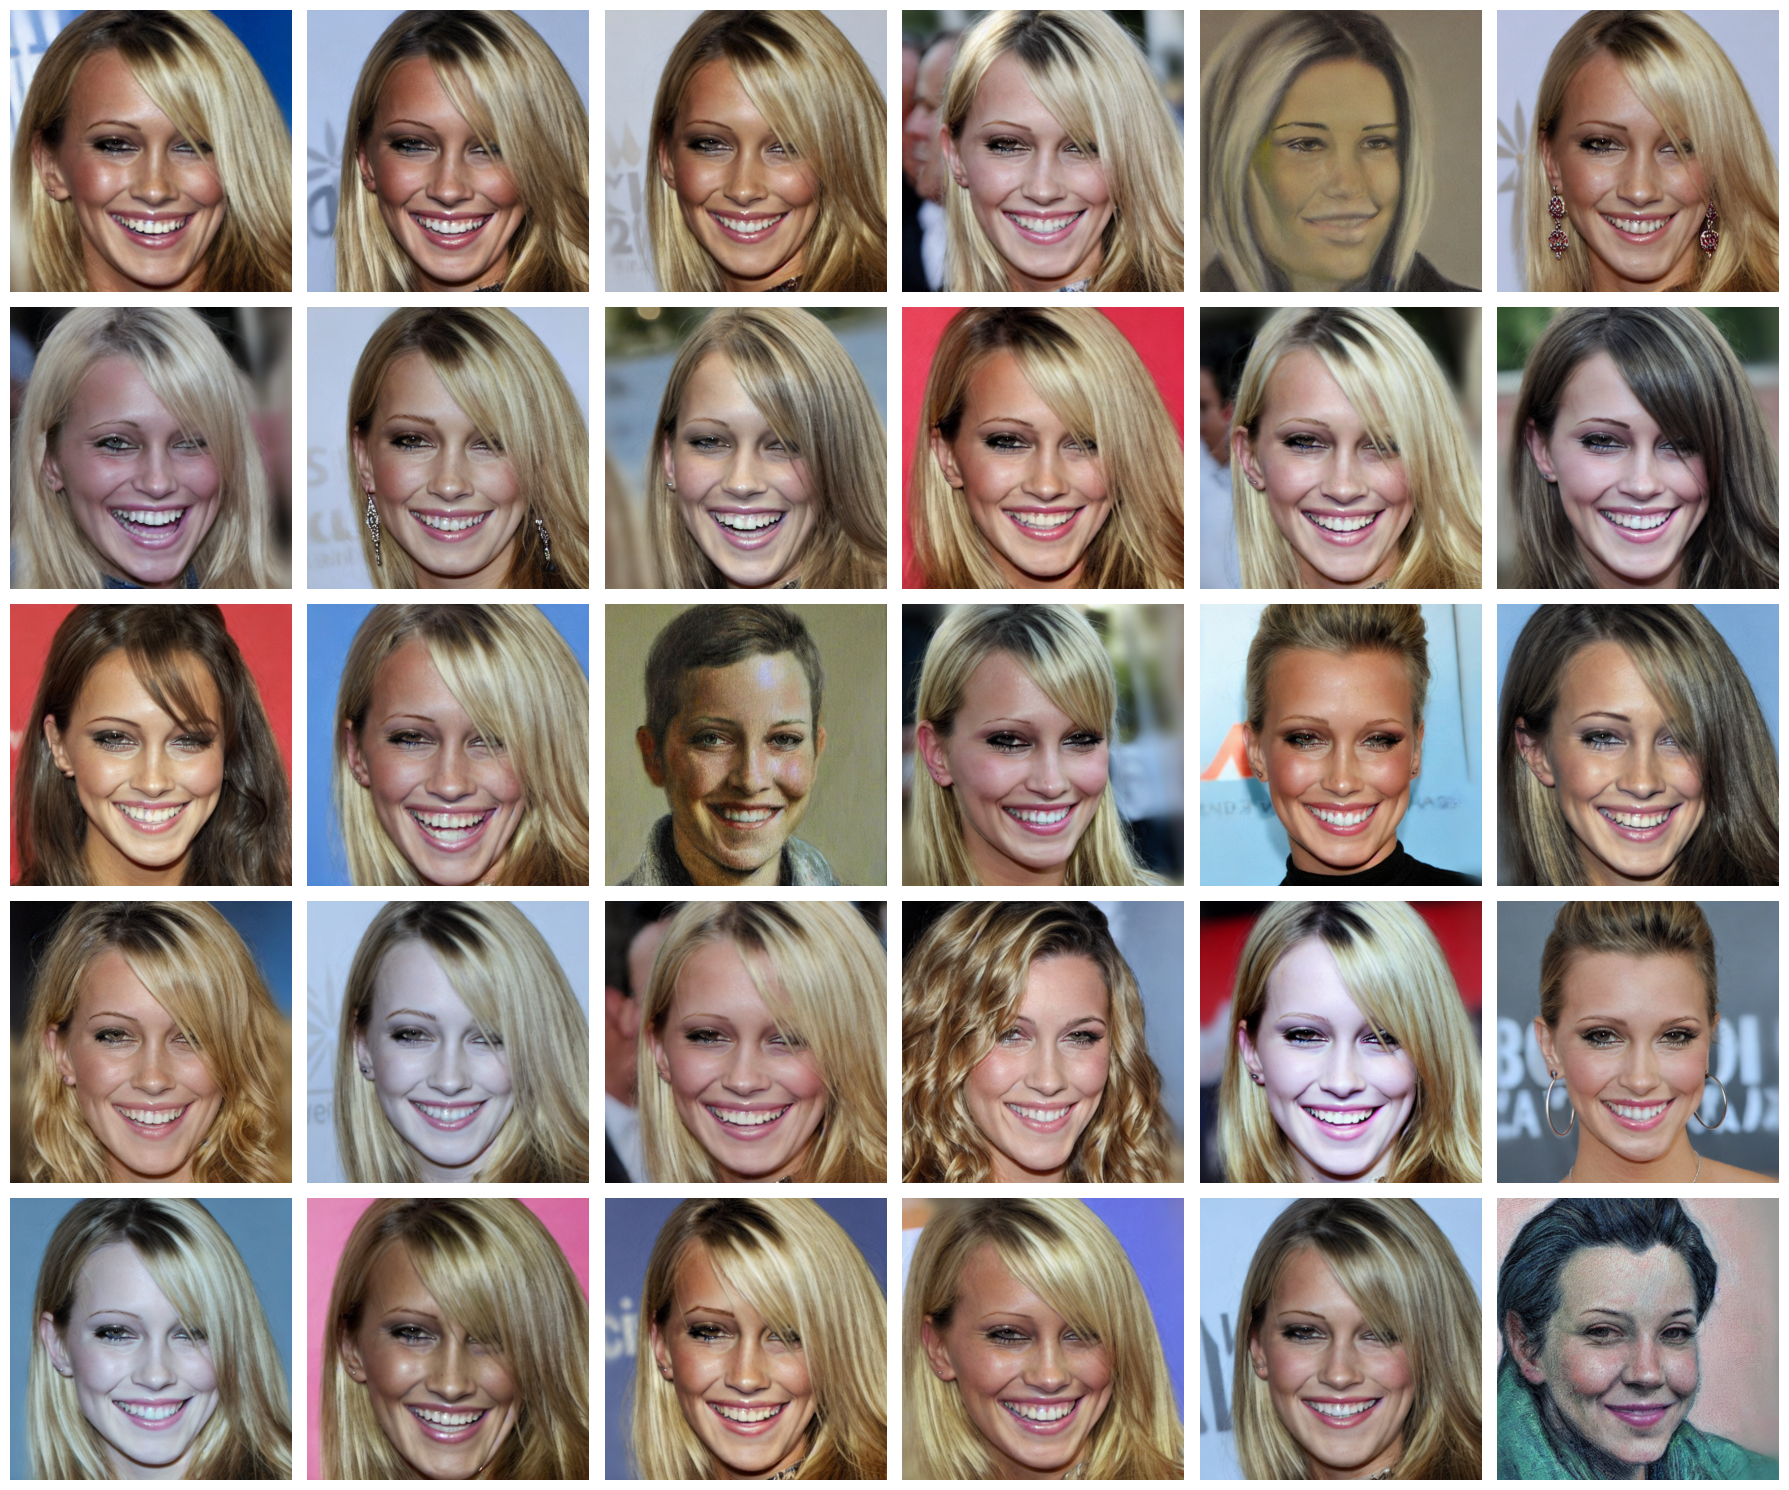

In [8]:
# ============================================================
# VISUALIZATION - SHOW 30 GENERATED IMAGES
# DREAMBOOTH 1-SHOT
# ============================================================

IDENTITY = 5247

IMAGE_DIR = f"/scratch/RDS_RS02810_AML/generated_DreamBooth_ID{IDENTITY}_5shot"

image_files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.endswith((".png", ".jpg", ".jpeg"))
])

selected = random.sample(image_files, 30)

fig, axes = plt.subplots(5, 6, figsize=(18, 15))

for ax, file in zip(axes.flatten(), selected):

    img = Image.open(os.path.join(IMAGE_DIR, file))

    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:

import os

from PIL import Image
from tqdm.auto import tqdm
from scipy.linalg import sqrtm
import glob
from torchvision import transforms
from torchvision.models import inception_v3

IDENTITY = 5247

REAL_DIR = "/scratch/RDS_RS02810_AML/personalization_data/identity_5247/five_shot/train"

FAKE_DIR = f"/scratch/RDS_RS02810_AML/generated_DreamBooth_ID{IDENTITY}_5shot"

In [10]:
device = "cuda"

model = inception_v3(
    pretrained=True,
    transform_input=False
).to(device)

model.fc = torch.nn.Identity()

model.eval()

transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
])

def get_activations(image_paths):

    activations = []

    with torch.no_grad():

        for path in tqdm(image_paths):

            img = Image.open(path).convert("RGB")

            tensor = transform(img).unsqueeze(0).to(device)

            feat = model(tensor)

            activations.append(
                feat.cpu().numpy().flatten()
            )

    return np.array(activations)

def calculate_fid(real_acts, fake_acts):

    mu1 = np.mean(real_acts, axis=0)
    mu2 = np.mean(fake_acts, axis=0)

    sigma1 = np.cov(real_acts, rowvar=False)
    sigma2 = np.cov(fake_acts, rowvar=False)

    diff = mu1 - mu2

    covmean = sqrtm(sigma1 @ sigma2)

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = (
        diff.dot(diff)
        + np.trace(sigma1 + sigma2 - 2 * covmean)
    )

    return fid

/scratch/RDS_RS02810_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/scratch/RDS_RS02810_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [11]:
REAL_DIR = "/scratch/RDS_RS02810_AML/personalization_data/identity_5247/all_images"

real_images = sorted([
    os.path.join(REAL_DIR, f)
    for f in os.listdir(REAL_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".webp"))
])

print("Num real images:", len(real_images))

real_acts = get_activations(real_images[:20])

print(real_acts.shape)

Num real images: 27


  0%|          | 0/20 [00:00<?, ?it/s]

(20, 2048)


In [12]:
gen_db_dir = "/scratch/RDS_RS02810_AML/generated_DreamBooth_ID5247_5shot"

gen_db = sorted(
    glob.glob(os.path.join(gen_db_dir, "*.png"))
)

# ONLY FIRST 20 GENERATED IMAGES
fake_acts_db = get_activations(gen_db[:20])

fid_db = calculate_fid(
    real_acts,
    fake_acts_db
)

print("\nDreamBooth 1-shot FID:", fid_db)

  0%|          | 0/20 [00:00<?, ?it/s]


DreamBooth 1-shot FID: 96.42043135603221


/scratch/RDS_RS02810_AML/.venv/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:149: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /user/HS400/rs02810/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /user/HS400/rs02810/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /user/HS400/rs02810/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /user/HS400/rs02810/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /user/HS400/rs02810/.insightface/models/buffalo_l/w600k_r50.onnx recognition [

  0%|          | 0/5 [00:00<?, ?it/s]

/scratch/RDS_RS02810_AML/.venv/lib/python3.12/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


  0%|          | 0/300 [00:00<?, ?it/s]

/scratch/RDS_RS02810_AML/.venv/lib/python3.12/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
/scratch/RDS_RS02810_AML/.venv/lib/python3.12/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
/scratch/RDS_RS02810_AML/.venv/lib/python3.12/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
/scratch/RDS_RS02810_AML/.venv/lib/python3.12/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is

FRS Mean: 0.2359
FRS Std : 0.1844


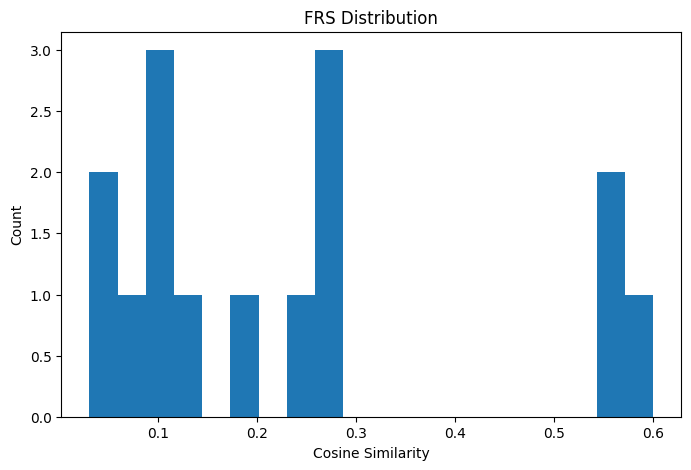

In [13]:
# ============================================================
# FRS USING INSIGHTFACE ARCFACE
# ============================================================
from tqdm.auto import tqdm
from insightface.app import FaceAnalysis
from sklearn.metrics.pairwise import cosine_similarity
import cv2

# ============================================================
# PATHS
# ============================================================

REAL_DIR = "/scratch/RDS_RS02810_AML/personalization_data/identity_5247/five_shot/train"

FAKE_DIR = "/scratch/RDS_RS02810_AML/generated_DreamBooth_ID5247_5shot"

real_images = [
    os.path.join(REAL_DIR, f)
    for f in os.listdir(REAL_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

fake_images = [
    os.path.join(FAKE_DIR, f)
    for f in os.listdir(FAKE_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

# ============================================================
# LOAD ARCFACE
# ============================================================

app = FaceAnalysis(
    name="buffalo_l",
    providers=["CUDAExecutionProvider"]
)

app.prepare(ctx_id=0)

# ============================================================
# EMBEDDING FUNCTION
# ============================================================

def get_embedding(img_path):

    img = cv2.imread(img_path)

    faces = app.get(img)

    if len(faces) == 0:
        return None

    return faces[0].embedding

# ============================================================
# REAL EMBEDDINGS
# ============================================================

real_embeddings = []

for path in tqdm(real_images):

    emb = get_embedding(path)

    if emb is not None:
        real_embeddings.append(emb)

real_embeddings = np.array(real_embeddings)

# ============================================================
# FRS COMPUTATION
# ============================================================

all_scores = []

for fake_path in tqdm(fake_images):

    fake_emb = get_embedding(fake_path)

    if fake_emb is None:
        continue

    sims = cosine_similarity(
        [fake_emb],
        real_embeddings
    )[0]

    best_sim = np.max(sims)

    all_scores.append(best_sim)

# ============================================================
# RESULTS
# ============================================================

mean_score = np.mean(all_scores)
std_score = np.std(all_scores)

print(f"FRS Mean: {mean_score:.4f}")
print(f"FRS Std : {std_score:.4f}")

# ============================================================
# HISTOGRAM
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(all_scores, bins=20)

plt.xlabel("Cosine Similarity")
plt.ylabel("Count")

plt.title("FRS Distribution")

plt.show()

In [14]:
# ============================================================
# DIVERSITY VIA ARCFACE EMBEDDING DISPERSION
# ============================================================

import numpy as np
from sklearn.metrics.pairwise import cosine_distances
from tqdm.auto import tqdm

embeddings = []

for img_path in tqdm(fake_images):

    emb = get_embedding(img_path)

    if emb is not None:

        embeddings.append(emb)

print("Valid embeddings:", len(embeddings))

embeddings = np.array(embeddings)

print("Embedding shape:", embeddings.shape)

# NEED AT LEAST 2 EMBEDDINGS
if len(embeddings) > 1:

    dist_matrix = cosine_distances(embeddings)

    upper_tri = dist_matrix[
        np.triu_indices_from(dist_matrix, k=1)
    ]

    dispersion = np.mean(upper_tri)

    print(f"\nEmbedding Dispersion: {dispersion:.4f}")

else:

    print("Not enough embeddings for diversity computation.")

  0%|          | 0/300 [00:00<?, ?it/s]

/scratch/RDS_RS02810_AML/.venv/lib/python3.12/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


Valid embeddings: 15
Embedding shape: (15, 512)

Embedding Dispersion: 0.9089


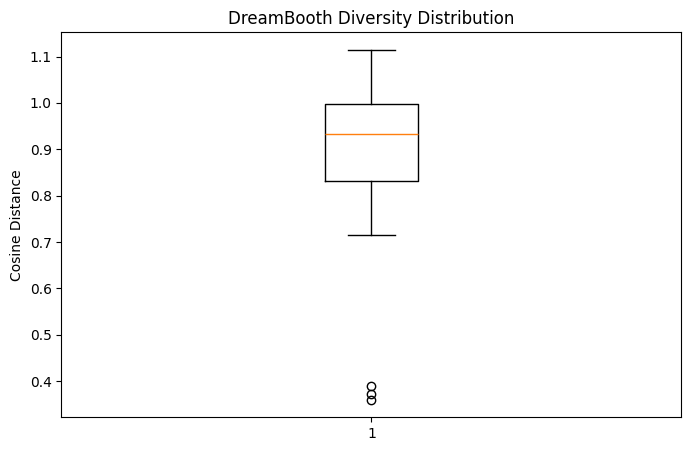

In [15]:
# ============================================================
# DIVERSITY BOXPLOT
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(upper_tri)

plt.ylabel("Cosine Distance")

plt.title("DreamBooth Diversity Distribution")

plt.show()

  0%|          | 0/5 [00:00<?, ?it/s]

/scratch/RDS_RS02810_AML/.venv/lib/python3.12/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


Valid train embeddings: 2


/scratch/RDS_RS02810_AML/.venv/lib/python3.12/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


Valid comparisons: 2


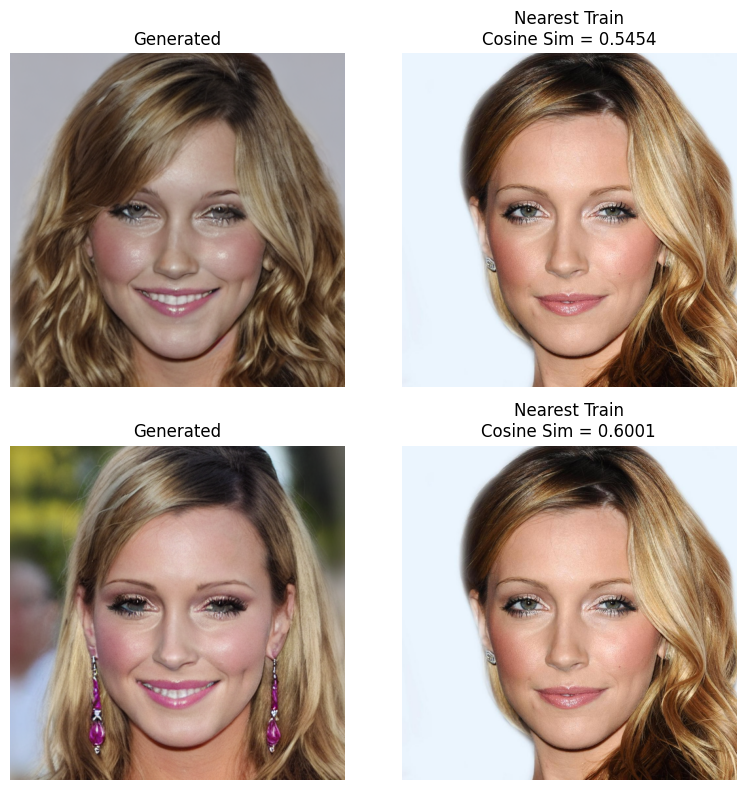

In [16]:
# ============================================================
# NEAREST-NEIGHBOUR MEMORIZATION ANALYSIS
# DREAMBOOTH VERSION
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================
# PATHS
# ============================================================

TRAIN_DIR = "/scratch/RDS_RS02810_AML/personalization_data/identity_5247/five_shot/train"

FAKE_DIR = "/scratch/RDS_RS02810_AML/generated_DreamBooth_ID5247_5shot"

train_images = sorted([
    os.path.join(TRAIN_DIR, f)
    for f in os.listdir(TRAIN_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

fake_images = sorted([
    os.path.join(FAKE_DIR, f)
    for f in os.listdir(FAKE_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

# ============================================================
# EMBEDDING FUNCTION
# ============================================================

def get_embedding(img_path):

    img = cv2.imread(img_path)

    if img is None:
        return None

    faces = app.get(img)

    if len(faces) == 0:
        return None

    face = sorted(
        faces,
        key=lambda x: x.bbox[2] * x.bbox[3],
        reverse=True
    )[0]

    return face.embedding

# ============================================================
# TRAIN EMBEDDINGS
# ============================================================

train_embeddings = []
valid_train_images = []

for img_path in tqdm(train_images):

    emb = get_embedding(img_path)

    if emb is not None:

        train_embeddings.append(emb)

        valid_train_images.append(img_path)

train_embeddings = np.array(train_embeddings)

print("Valid train embeddings:", len(train_embeddings))

# ============================================================
# RANDOM SAMPLE
# ============================================================

selected_fake = random.sample(
    fake_images,
    min(100, len(fake_images))
)

results = []

for fake_img in selected_fake:

    fake_emb = get_embedding(fake_img)

    if fake_emb is None:
        continue

    sims = cosine_similarity(
        [fake_emb],
        train_embeddings
    )[0]

    idx = np.argmax(sims)

    nearest_train = valid_train_images[idx]

    results.append(
        (
            fake_img,
            nearest_train,
            sims[idx]
        )
    )

print("Valid comparisons:", len(results))

# ============================================================
# VISUALIZE
# ============================================================

num_show = min(10, len(results))

fig, axes = plt.subplots(
    num_show,
    2,
    figsize=(8, 4 * num_show)
)

if num_show == 1:
    axes = [axes]

for row in range(num_show):

    fake_img, nearest_train, sim = results[row]

    fake_pil = Image.open(fake_img).convert("RGB")

    train_pil = Image.open(nearest_train).convert("RGB")

    axes[row][0].imshow(fake_pil)
    axes[row][0].set_title("Generated")
    axes[row][0].axis("off")

    axes[row][1].imshow(train_pil)
    axes[row][1].set_title(
        f"Nearest Train\nCosine Sim = {sim:.4f}"
    )
    axes[row][1].axis("off")

plt.tight_layout()

plt.show()